In [1]:
#Kode Pembuat Data

import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")
cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

np.random.seed(42)
for kota, kode in cabang_kota.items():
    n_rows = np.random.randint(80, 120)
    data_cabang = {
        "id_transaksi": [f"TRX-{kode}-{i+1:04d}" for i in range(n_rows)],
        "tanggal": np.random.choice(tanggal_range, size=n_rows),
        "kategori": np.random.choice(kategori_list, size=n_rows),
        "unit_terjual": np.random.randint(1, 10, size=n_rows),
        "harga_satuan": np.random.choice([15000, 50000, 150000, 500000, 1200000], size=n_rows),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n_rows)
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 118 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 110 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 116 baris


In [2]:
# a. Membangun Struktur Direktori HDFS

# Membuat folder raw dan processed
!hdfs dfs -mkdir -p /user/$USER/ecommerce/raw
!hdfs dfs -mkdir -p /user/$USER/ecommerce/processed

# Verifikasi struktur direktori
!hdfs dfs -ls /user/$USER/ecommerce

Found 2 items
drwxr-xr-x   - hans supergroup          0 2026-09-09 23:03 /user/hans/ecommerce/processed
drwxr-xr-x   - hans supergroup          0 2026-09-09 23:03 /user/hans/ecommerce/raw


In [3]:
# b. Mengunggah Data Mentah ke HDF

# Unggah seluruh file CSV cabang sekaligus
!hdfs dfs -put transaksi_*.csv /user/$USER/ecommerce/raw/

# Verifikasi daftar file dan ukurannya di HDFS
!hdfs dfs -ls -h /user/$USER/ecommerce/raw

Found 3 items
-rw-r--r--   1 hans supergroup      7.8 K 2026-09-09 23:05 /user/hans/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 hans supergroup      7.5 K 2026-09-09 23:05 /user/hans/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 hans supergroup      7.3 K 2026-09-09 23:05 /user/hans/ecommerce/raw/transaksi_yogyakarta.csv


In [5]:
# Intsal dulu wokk!!
!pip install hdfs

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hdfs: filename=hdfs-2.7.3-py3-none-any.whl size=34431 sha256=a6c5335a4943d0df0a5723b32bcf7cbb3cae4528dcdf5592db159a64c7f662a7
  Stored in directory: /home/hans/.cache/pip/wheels/b9/1d/dc/eb0833be25464c359903d356c4204721c6a672c26ff164cdc3
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13783 sha256=e45fd6dff0804fdf5f929da5d51649ff7a4ad35dcccb157935b63fcae9199833
  Stored in directory: /home/hans/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built hdfs docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [hdfs]


In [9]:
# c. Membaca Kembali dan Menggabungkan Data dari HDFS

import pandas as pd
from hdfs import InsecureClient

# Hubungkan ke HDFS NameNode menggunakan user 'hans'
client = InsecureClient('http://localhost:9870', user='hans')

files = ['transaksi_magelang.csv', 'transaksi_yogyakarta.csv', 'transaksi_semarang.csv']
df_list = []

for file_name in files:
    hdfs_path = f'/user/hans/ecommerce/raw/{file_name}'
    with client.read(hdfs_path) as reader:
        df_list.append(pd.read_csv(reader))

# Penggabungan DataFrame
df_gabungan = pd.concat(df_list, ignore_index=True)

# Bukti verifikasi data ketiga kota
print(df_gabungan['kota'].value_counts())

kota
Magelang      118
Semarang      116
Yogyakarta    110
Name: count, dtype: int64


In [13]:
# d. Mengolah dan Mengunggah Hasil ke Direktori Processed

# 1. Hitung total pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# 2. Ringkasan total pendapatan per kota dan kategori
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

# 3. Simpan sementara ke lokal
df_gabungan.to_csv('data_gabungan_bersih.csv', index=False)
df_ringkasan.to_csv('ringkasan_kota_kategori.csv', index=False)

print(" Berkas lokal berhasil dibuat. Berikut pratinjau ringkasannya:")
display(df_ringkasan)

 Berkas lokal berhasil dibuat. Berikut pratinjau ringkasannya:


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,51635000
1,Magelang,Fashion,35165000
2,Magelang,Kesehatan & Kecantikan,23745000
3,Magelang,Makanan & Minuman,54055000
4,Magelang,Rumah Tangga,53980000
5,Semarang,Elektronik,48580000
6,Semarang,Fashion,87055000
7,Semarang,Kesehatan & Kecantikan,38525000
8,Semarang,Makanan & Minuman,27890000
9,Semarang,Rumah Tangga,31880000


In [14]:
# Unggah kedua file hasil pemrosesan ke zona processed HDFS:

!hdfs dfs -put data_gabungan_bersih.csv /user/$USER/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/$USER/ecommerce/processed/

# Verifikasi isi folder processed
!hdfs dfs -ls -h /user/$USER/ecommerce/processed

Found 2 items
-rw-r--r--   1 hans supergroup     25.0 K 2026-09-09 23:17 /user/hans/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 hans supergroup        530 2026-09-09 23:17 /user/hans/ecommerce/processed/ringkasan_kota_kategori.csv


# E. Dokumentasi dan Refleksi

### 1. Screenshot NameNode Web UI
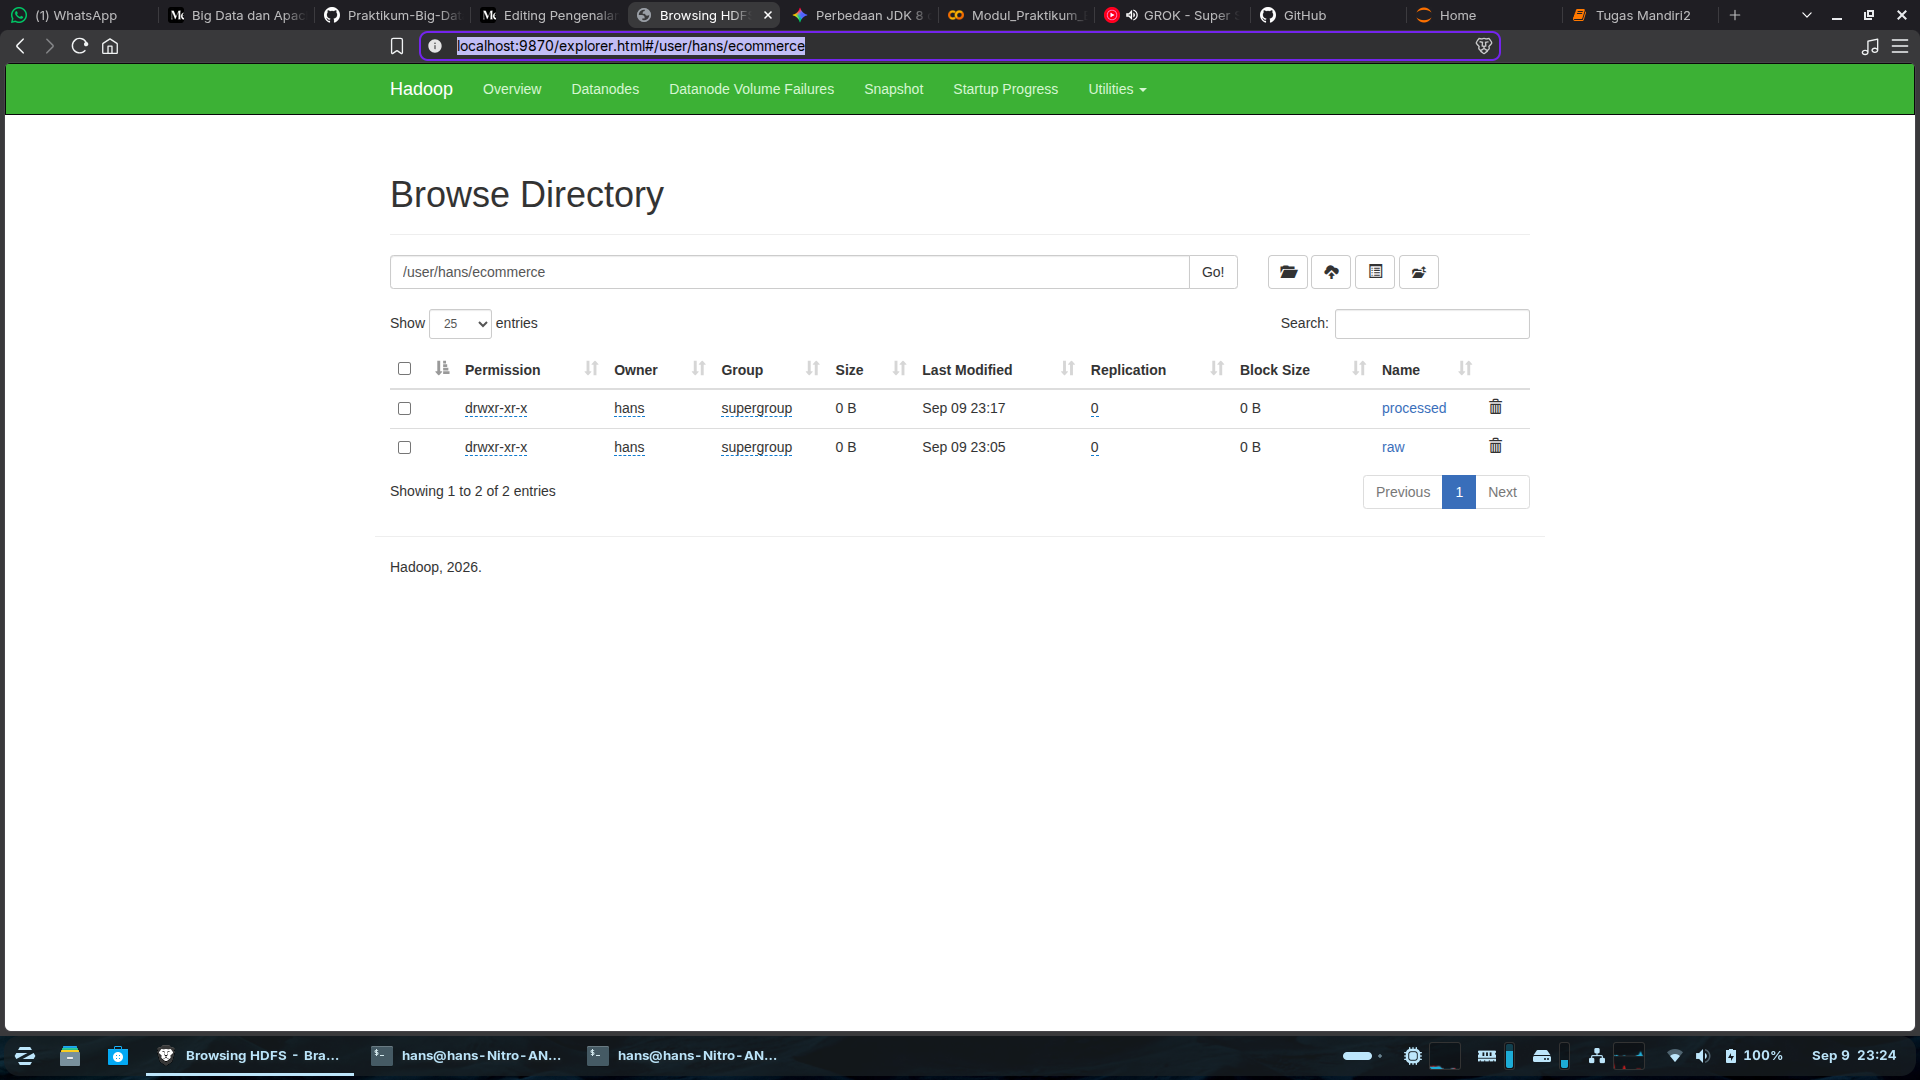

### 2. Tulisan Refleksi
Menurut pemahaman saya, pemisahan direktori antara data mentah (*raw*) dan data olahan (*processed*) di HDFS memiliki beberapa keuntungan yang sangat krusial dalam arsitektur Big Data:

1. **Menjaga Integritas Data (Data Immutability):** Data mentah bertindak sebagai *single source of truth* (sumber kebenaran tunggal) yang bersifat murni dan tidak boleh diubah. Jika suatu saat terjadi kesalahan logika pada skrip pengolahan data atau ada kebutuhan analisis baru, kita selalu bisa memproses ulang dari data asli tanpa risiko kehilangan data awal.
2. **Keamanan dan Tata Kelola Akses (Data Governance):** Kita dapat menerapkan pembatasan hak akses (*permission*) yang berbeda. Folder *raw* bisa dikunci agar hanya bisa diakses oleh *data engineer*, sedangkan folder *processed* dibuka untuk tim *data analyst* atau *business intelligence* untuk kebutuhan *reporting*.
3. **Kerapian dan Efisiensi Pipeline Data:** Pemisahan ini mempermudah alur kerja ETL/ELT. Tim teknis dapat dengan mudah membedakan mana data yang masih perlu dibersihkan dan mana data yang sudah siap dikonsumsi oleh aplikasi analytical/machine learning tanpa kebingungan akibat file yang tercampur dalam satu direktori.